# Diffusion Models with Keras


## 1. What is a diffusion model?

A diffusion model is a generative model that learns how to create data by reversing a noising process.

The logic is this:

1. Start with a real image.
2. Add noise to it gradually over many steps.
3. Train a neural network to predict the noise that was added.
4. At generation time, start from random noise and repeatedly remove noise step by step.

So the model does not directly generate an image in one step. It learns how to move from noisy data back toward structured data.

This is the key idea:

- **forward process**: gradually destroy structure by adding noise
- **reverse process**: learn how to remove that noise

That is why diffusion models became powerful for image generation. They are trained with a very clear objective: predict noise correctly at different noise levels.


## 2. Why diffusion models matter

Diffusion models matter because they are one of the strongest approaches for modern generative image systems.

They are used in systems for:

- image generation from noise
- text-to-image generation
- image editing
- super-resolution
- inpainting
- conditional generation

Their strength comes from stable training and strong output quality.


## 4. Import the libraries

We import:

- `numpy` for numerical operations
- `matplotlib` for plotting
- `tensorflow` / `keras` for building and training the model

We keep the setup clean and minimal.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model

## 5. Load the dataset

We use MNIST because it is small, fast, and easy to visualize.

Each image is:

- grayscale
- shape `28 x 28`
- a handwritten digit

This dataset is simple enough to let you focus on the diffusion logic rather than heavy compute.


In [2]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


## 6. Inspect sample images

Before building anything, inspect the data.

If you skip data inspection, you are training blindly. That is weak practice.

Here we display a few MNIST examples so you stay grounded in what the model is actually learning from.


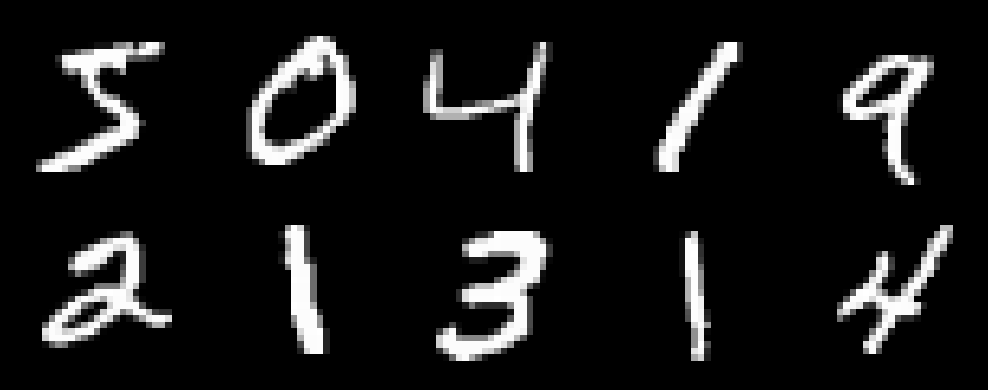

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Preprocess the images

We normalize the pixel values and reshape the images.

For this simplified setup, we keep the images with a channel dimension so that the model can process them as image tensors.

The expected final shape is:

`(num_samples, 28, 28, 1)`

We also move values into a smaller numerical range to make training easier and more stable.


In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Move values from [0, 1] to [-1, 1]
x_train = (x_train * 2.0) - 1.0
x_test = (x_test * 2.0) - 1.0

print("Processed x_train shape:", x_train.shape)
print("Processed x_test shape:", x_test.shape)

Processed x_train shape: (60000, 28, 28, 1)
Processed x_test shape: (10000, 28, 28, 1)


## 8. Define the diffusion schedule

A diffusion model needs a noise schedule.

At each time step `t`, we define how much noise is added.

Common notation:

- `beta_t`: variance schedule for each step
- `alpha_t = 1 - beta_t`
- `alpha_hat_t`: cumulative product of alphas up to step `t`

Why do we need this?

Because the forward process is not just random chaos. It follows a controlled schedule that tells us exactly how much of the original image and how much of the noise should be present at each step.

This schedule is one of the foundations of the whole method.


In [7]:
timesteps = 200

beta_start = 1e-4
beta_end = 0.02

betas = np.linspace(beta_start, beta_end, timesteps, dtype=np.float32)
alphas = 1.0 - betas
alpha_hat = np.cumprod(alphas)

sqrt_alpha_hat = np.sqrt(alpha_hat)
sqrt_one_minus_alpha_hat = np.sqrt(1.0 - alpha_hat)

print("betas shape:", betas.shape)
print("alpha_hat shape:", alpha_hat.shape)

betas shape: (200,)
alpha_hat shape: (200,)


## 9. Define a helper function for the forward diffusion process

The forward process creates a noisy image from a clean image at a chosen time step.

The important formula is:

`x_t = sqrt(alpha_hat_t) * x_0 + sqrt(1 - alpha_hat_t) * noise`

Where:

- `x_0` is the original clean image
- `noise` is Gaussian noise
- `x_t` is the noisy image at time step `t`

This formula matters. Do not just paste it. Understand it.

It means the noisy image is a weighted mixture of:

- the original image
- random noise

As time increases, the image becomes more dominated by noise.


In [8]:
def forward_diffusion_sample(x0, t):
    noise = tf.random.normal(shape=tf.shape(x0))

    sqrt_alpha_hat_t = tf.gather(sqrt_alpha_hat, t)
    sqrt_one_minus_alpha_hat_t = tf.gather(sqrt_one_minus_alpha_hat, t)

    sqrt_alpha_hat_t = tf.reshape(sqrt_alpha_hat_t, (-1, 1, 1, 1))
    sqrt_one_minus_alpha_hat_t = tf.reshape(sqrt_one_minus_alpha_hat_t, (-1, 1, 1, 1))

    xt = sqrt_alpha_hat_t * x0 + sqrt_one_minus_alpha_hat_t * noise
    return xt, noise

## 10. Encode time information

The model must know at what diffusion step it is working.

Why?

Because denoising an image at an early step is not the same as denoising one at a very late noisy step.

So we provide the time step as an additional input.

In advanced models, time is usually encoded using sinusoidal embeddings. In this learning notebook, we use a simpler embedding approach that is easier to follow.


## 11. Build a simple noise-prediction model in Keras

The model takes:

- a noisy image
- a time step

And it predicts:

- the noise that was added

This is the central training target in diffusion models.

We are not training the model to directly output the clean image. We train it to predict the noise.

That distinction is critical. If that is still fuzzy in your head, stop and fix it before moving on.


In [9]:
def build_time_embedding(time_input, embedding_dim=32):
    x = layers.Embedding(input_dim=timesteps, output_dim=embedding_dim)(time_input)
    x = layers.Dense(embedding_dim, activation="relu")(x)
    x = layers.Dense(embedding_dim, activation="relu")(x)
    return x

image_input = keras.Input(shape=(28, 28, 1), name="noisy_image")
time_input = keras.Input(shape=(), dtype=tf.int32, name="time_step")

time_embedding = build_time_embedding(time_input, embedding_dim=32)
time_embedding = layers.Reshape((1, 1, 32))(time_embedding)
time_embedding = layers.UpSampling2D(size=(28, 28))(time_embedding)

x = layers.Concatenate()([image_input, time_embedding])

x = layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")(x)
x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
x = layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")(x)
output = layers.Conv2D(1, kernel_size=3, padding="same", activation=None)(x)

diffusion_model = Model([image_input, time_input], output, name="simple_diffusion_model")
diffusion_model.summary()

 Non-trainable params: 0 (0.00 B)

## 12. Compile the model

We now compile the model with:

- an optimizer
- a loss function

For this educational setup, mean squared error is a natural choice because the target is the added Gaussian noise, and the model is learning a continuous regression task.


In [10]:
diffusion_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

## 13. Prepare a training step

At each training iteration, we:

1. sample clean images
2. sample random time steps
3. sample Gaussian noise
4. create noisy versions of the clean images
5. ask the model to predict the added noise
6. compare predicted noise with the true noise

This is the training loop conceptually.

Even if you later use `fit()` with a dataset pipeline, you must understand this logic.


In [11]:
batch_size = 128
epochs = 10

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

## 14. Train the diffusion model

We train over multiple epochs.

The model gradually learns how noisy images at different time steps relate to the original hidden signal and the noise component.

Training diffusion models can be slow in large settings, but on MNIST with a compact model it is manageable for learning.


In [12]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = keras.losses.MeanSquaredError()

train_losses = []

for epoch in range(epochs):
    epoch_losses = []

    for batch_images in train_dataset:
        current_batch_size = tf.shape(batch_images)[0]
        t = tf.random.uniform(
            minval=0,
            maxval=timesteps,
            shape=(current_batch_size,),
            dtype=tf.int32
        )

        noisy_images, noise = forward_diffusion_sample(batch_images, t)

        with tf.GradientTape() as tape:
            predicted_noise = diffusion_model([noisy_images, t], training=True)
            loss = loss_fn(noise, predicted_noise)

        gradients = tape.gradient(loss, diffusion_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, diffusion_model.trainable_variables))

        epoch_losses.append(float(loss.numpy()))

    mean_loss = np.mean(epoch_losses)
    train_losses.append(mean_loss)
    print(f"Epoch {epoch + 1}/{epochs} - loss: {mean_loss:.6f}")

Epoch 10/10 - loss: 0.061059


## 15. Plot training loss

Loss curves help you see whether the model is learning noise prediction at all.

Do not just trust that the code works. Inspect the learning signal.


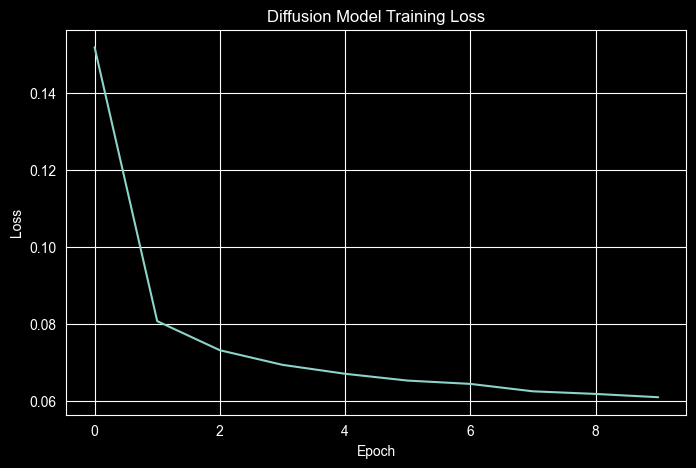

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Diffusion Model Training Loss")
plt.show()

## 16. Define the reverse sampling process

Generation works in reverse.

We start from pure random noise and apply the model repeatedly to predict and remove noise step by step.

This is the reverse diffusion process.

In full formulations, this involves carefully derived update rules. In this notebook, we keep the reverse loop simple enough to understand while still staying faithful to the main idea.


In [14]:
def sample_images(model, num_samples=16):
    x = tf.random.normal(shape=(num_samples, 28, 28, 1))

    for t in reversed(range(timesteps)):
        t_batch = tf.fill([num_samples], t)
        predicted_noise = model([x, t_batch], training=False)

        alpha_t = alphas[t]
        alpha_hat_t = alpha_hat[t]
        beta_t = betas[t]

        x = (1 / np.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / np.sqrt(1 - alpha_hat_t)) * predicted_noise
        )

        if t > 0:
            noise = tf.random.normal(shape=tf.shape(x))
            x = x + np.sqrt(beta_t) * noise

    return x

## 17. Generate sample images

Now we test whether the learned reverse process can transform noise into digit-like images.

This is the point where the method becomes visually real.

If the model learned something useful, the final samples should begin to show meaningful structure rather than only static noise.


In [15]:
generated_images = sample_images(diffusion_model, num_samples=16)
generated_images = generated_images.numpy()

## 18. Visualize generated samples

We display multiple generated images in a grid.

This helps you judge whether the reverse process is producing recognizable patterns.


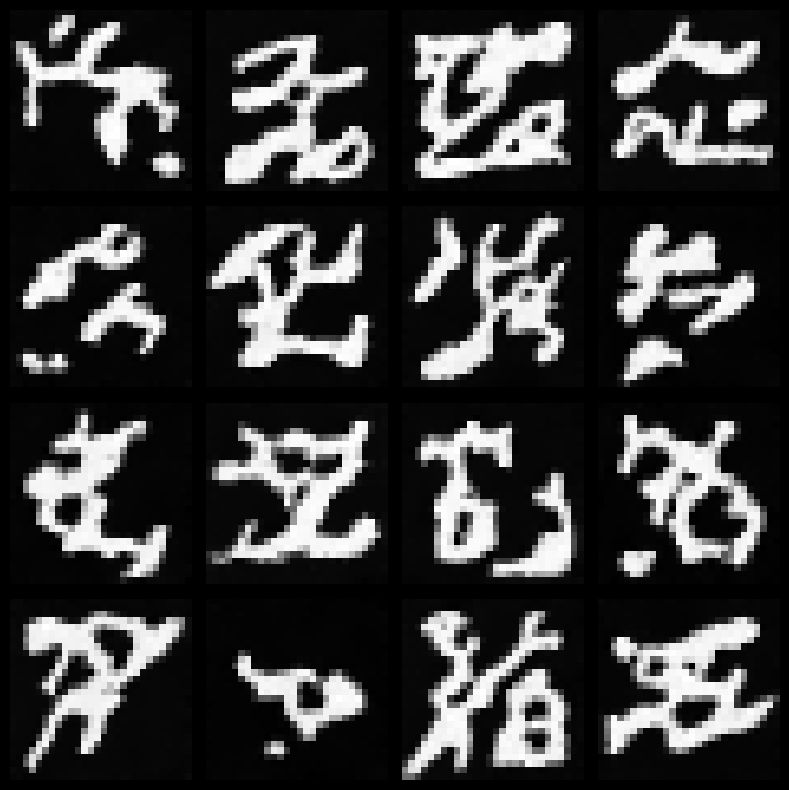

In [16]:
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()